In [1]:
import numpy as np
import matplotlib.pyplot as plt
import copy
from scipy.signal import detrend

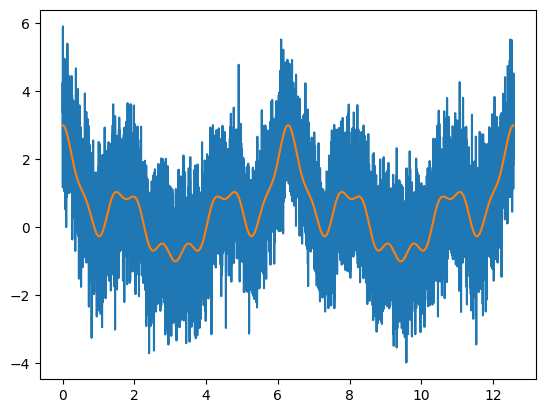

In [2]:
N = 10001
time = np.linspace(0,4*np.pi,N)

signal = np.zeros(N)

for j in range(1,4):
  signal += np.cos(j*time)**j

noisysignal = signal + np.random.randn(N)

plt.plot(time,noisysignal, time,signal)
plt.show()

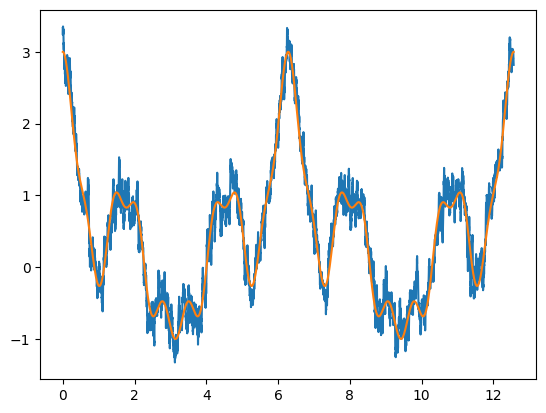

In [3]:
# Mean Smoothing Filter
filtered_signal = copy.deepcopy(noisysignal)

k = 15

for t in range(N):
  lower_bound = np.max((0,t-k))
  upper_bound = np.min((N,t+k))
  filtered_signal[t] = np.mean(noisysignal[lower_bound:upper_bound])

plt.plot(time,filtered_signal, time,signal)
plt.show()

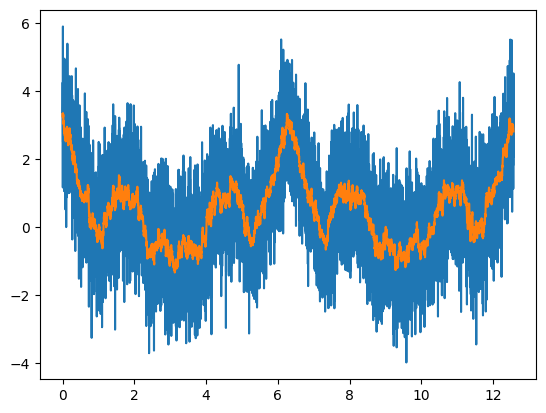

In [4]:
plt.plot(time, noisysignal, time, filtered_signal)

In [5]:
def mean_smooth(signalIn, k):
  filtered_signal = copy.deepcopy(signalIn)

  for t in range(N):
    filtered_signal[t] = np.mean(noisysignal[np.max((0,t-k)):np.min((N,t+k))])
  return filtered_signal

k_values = np.arange(5, 41)
signal_corrs = []


for k_index in k_values:
  # filter the signal
  f_signal = mean_smooth(noisysignal, k_index)

  # compute the correlation signal and original
  signal_corrs.append(np.corrcoef(f_signal, signal)[0, 1])

In [6]:
signal_corrs

[np.float64(0.950143462073496),
 np.float64(0.9574462798078479),
 np.float64(0.9630422990903584),
 np.float64(0.9671479254960532),
 np.float64(0.970323144589973),
 np.float64(0.972921103104723),
 np.float64(0.9750822253547358),
 np.float64(0.9769574355360214),
 np.float64(0.9785727927858368),
 np.float64(0.9799413453763652),
 np.float64(0.981154731668616),
 np.float64(0.9822485395441619),
 np.float64(0.9832342437212447),
 np.float64(0.9840932300390475),
 np.float64(0.9848782058778295),
 np.float64(0.9855833716445166),
 np.float64(0.9862324241336111),
 np.float64(0.9868322964857613),
 np.float64(0.9873945264473993),
 np.float64(0.9879082504696397),
 np.float64(0.9883905633790641),
 np.float64(0.9888355742356955),
 np.float64(0.9892457010248678),
 np.float64(0.9896261672678444),
 np.float64(0.9899864832276464),
 np.float64(0.9903314913289663),
 np.float64(0.9906543129468278),
 np.float64(0.9909504995156804),
 np.float64(0.9912238794308729),
 np.float64(0.991469567197475),
 np.float64(0.9

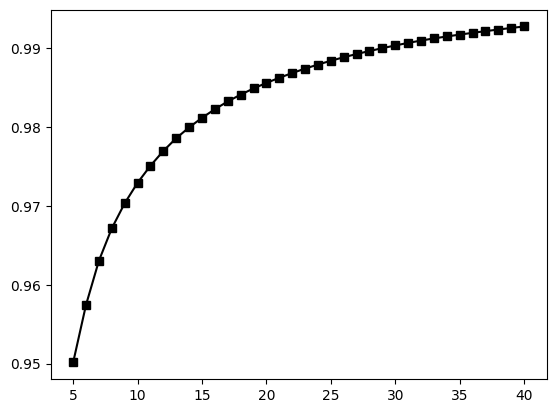

In [7]:
plt.plot(k_values, signal_corrs, 'ks-')

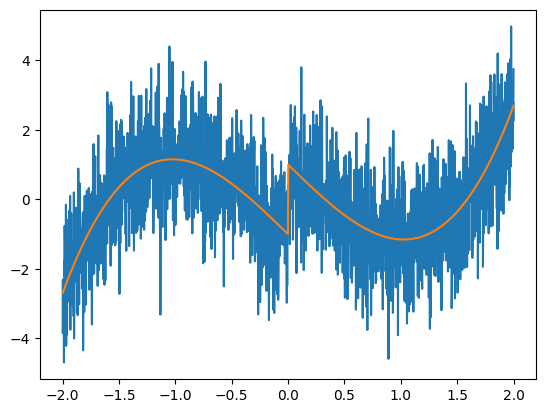

In [8]:
# Smooth via Gaussian Convoltion
# create signal

srate = 512
time = np.arange(-2, 2 + 1 / srate, 1 / srate)
points = len(time)

signal = detrend(time**3 + np.sign(time))
noisysignal = signal + np.random.randn(points) * 1.1

plt.plot(time, noisysignal, time, signal)

Text(0.5, 1.0, 'n=21, s=0.005')

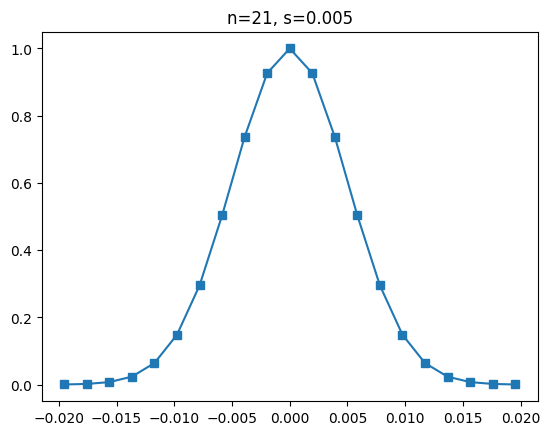

In [9]:
# Create the Gaussian
k = 10
x = np.arange(-k, k + 1) / srate
s = 0.005

gkern = np.exp(-x**2 / (2 * s**2))

plt.plot(x, gkern, 's-')
plt.title('n=%s, s=%g'%(2 * k + 1, s))

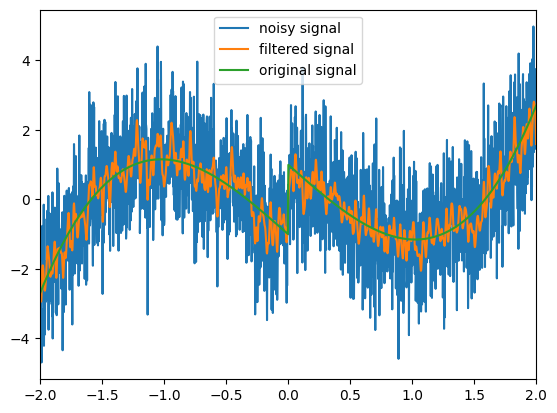

In [14]:
# Gaussian smoothing filter

gkern /= sum(gkern)

filtered_signal = np.convolve(noisysignal, gkern, mode='same')

plt.plot(time, noisysignal, time, filtered_signal, time, signal)
plt.legend(['noisy signal', 'filtered signal', 'original signal'])
plt.xlim(time[[0,-1]])
plt.show()